# Braids on Geek

A notebook for looking at braids: how they're drawn, where the strands go, and what their Burau matrix is.

**How to use it:** click a cell and press **Shift+Enter** to run it, or simply click **Run all** at the top left commands. Run the cells from top to bottom the first time. Change anything you like and run it again.

*First draft. Rewrite the explanations in your own words as you go.*

In [1]:
# Setup for Google Colab. Colab opens only this notebook, not the rest of the
# project, so it can't find braids.py and drawing.py. This cell downloads the
# project from GitHub and moves into it. On your own computer it does nothing.
import os, subprocess, sys

if "google.colab" in sys.modules and not os.path.exists("braids.py"):
    if not os.path.exists("Braids-on-Geek"):
        subprocess.run(["git", "clone", "-q", "https://github.com/dora-mitic/Braids-on-Geek.git"], check=True)
    os.chdir("Braids-on-Geek")

In [2]:
from braids import PRESETS, burau_matrix, inverse_word, permutation, word_to_string
from drawing import draw_braid
import matplotlib.pyplot as plt

## 1. A braid is a list of crossings

A braid on `n` strands is written as a list of crossings from top to bottom, the **braid word**.

- `(i, +1)` is **σᵢ**: the strand at position *i* crosses **over** its right neighbour.
- `(i, -1)` is **σᵢ⁻¹**: it crosses **under**.

Here's the everyday hair braid: left over middle, right over middle, repeated.

σ₁ σ₂⁻¹ σ₁ σ₂⁻¹ σ₁ σ₂⁻¹


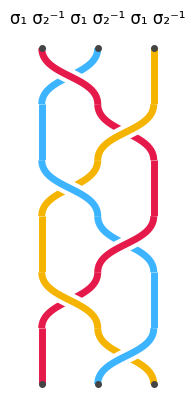

In [3]:
n, word = PRESETS["plain 3-strand braid"]
print(word_to_string(word))
draw_braid(word, n);

## 2. The permutation: where does each strand end up?

Label the strands 0, 1, 2, ... by where they start at the top. The permutation lists which strand ends at each position at the bottom.

It forgets over and under, so σ₁ and σ₁⁻¹ give the same permutation. The colors in the drawing show it: follow a color from top to bottom.

σ₁ σ₂ -> [1, 2, 0]


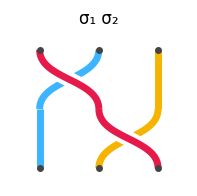

In [4]:
word = [(1, +1), (2, +1)]
n = 3
print(word_to_string(word), "->", permutation(word, n))
draw_braid(word, n);

## 3. The Burau matrix: a braid as a matrix

Each crossing becomes an `n × n` matrix with entries in `t`, and a whole braid becomes the product of its crossings' matrices. Unlike the permutation, this *does* remember over and under.

Two things to notice:
- Every row adds up to 1.
- Putting `t = 1` gives the plain permutation matrix, so Burau is a "t-version" of the permutation.

In [5]:
burau_matrix([(1, +1)], 2)

Matrix([
[1 - t, t],
[    1, 0]])

In [6]:
burau_matrix([(1, -1)], 2)

Matrix([
[  0,         1],
[1/t, (t - 1)/t]])

In [7]:
burau_matrix([(1, +1), (2, +1)], 3)

Matrix([
[1 - t, t*(1 - t), t**2],
[    1,         0,    0],
[    0,         1,    0]])

In [8]:
# the same braid at t = 1: a permutation matrix
burau_matrix([(1, +1), (2, +1)], 3, t_value=1)

array([[0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.]])

## 4. Different words, same braid

**The braid relation**: σ₁σ₂σ₁ = σ₂σ₁σ₂. The pictures look different, but you can slide the strands from one into the other without cutting anything. So they must give the same matrix.

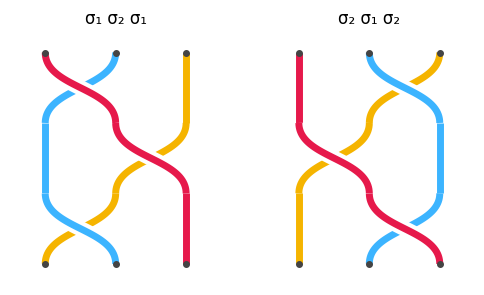

same matrix? True


In [9]:
n, left = PRESETS["braid relation, left side"]
_, right = PRESETS["braid relation, right side"]

fig, axes = plt.subplots(1, 2, figsize=(6, 4))
draw_braid(left, n, ax=axes[0])
draw_braid(right, n, ax=axes[1])
plt.show()

print("same matrix?", burau_matrix(left, n) == burau_matrix(right, n))

**Undoing a crossing**: a braid followed by its inverse is the "do nothing" braid, whose matrix is the identity.

σ₁ σ₂⁻¹ σ₁ σ₁⁻¹ σ₂ σ₁⁻¹


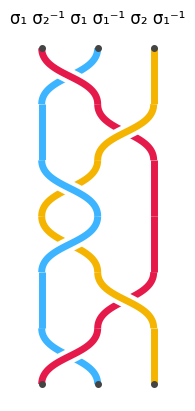

Matrix([
[1, 0, 0],
[0, 1, 0],
[0, 0, 1]])

In [10]:
word = [(1, +1), (2, -1), (1, +1)]
glued = word + inverse_word(word)
print(word_to_string(glued))
draw_braid(glued, 3)
plt.show()
burau_matrix(glued, 3)

## 5. Your turn

Change `word` and `n` and run the cell. (`i` must be between 1 and `n - 1`.)

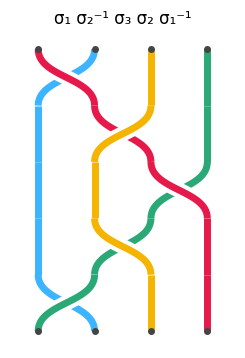

permutation: [3, 1, 2, 0]


Matrix([
[    1 - t,    t*(1 - t), 0,  t**2],
[        0,            1, 0,     0],
[(1 - t)/t, -t + 2 - 1/t, 1, t - 1],
[      1/t,    (t - 1)/t, 0,     0]])

In [11]:
word = [(1, +1), (2, -1), (3, +1), (2, +1), (1, -1)]
n = 4

draw_braid(word, n)
plt.show()
print("permutation:", permutation(word, n))
burau_matrix(word, n)